Disease Prediction System Using Machine Learning

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("cardio_train.csv",sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [8]:
print("Shape:", df.shape)

Shape: (70000, 13)


In [9]:
display(df.describe())

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
print(df.isnull().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [11]:
df[(df['ap_hi'] <= 0) | (df['ap_lo'] <= 0)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
2014,2845,22712,2,167,59.0,906,0,1,1,0,0,1,0
4607,6525,15281,1,165,78.0,-100,80,2,1,0,0,1,0
13489,19258,14965,2,150,60.0,130,0,1,1,0,0,0,0
16021,22881,22108,2,161,90.0,-115,70,1,1,0,0,1,0
16459,23512,20457,1,156,50.0,138,0,3,1,0,0,1,1
17381,24837,18226,1,164,78.0,138,0,1,1,0,0,1,0
20536,29313,15581,1,153,54.0,-100,70,1,1,0,0,1,0
22923,32749,21182,2,166,68.0,149,0,1,1,0,0,1,1
23867,34120,16131,1,161,92.0,906,0,2,1,0,0,1,1
23988,34295,18301,1,162,74.0,-140,90,1,1,0,0,1,1


In [15]:
df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [17]:
df = df[
    (df['ap_hi'] >= 80) &
    (df['ap_hi'] <= 250) &
    (df['ap_lo'] >= 40) &
    (df['ap_lo'] <= 200)
]
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [18]:
df[(df['height'] < 100) | (df['height'] > 220)]

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
224,309,21800,2,76,55.0,120,80,1,1,0,0,1,0
6486,9223,21220,1,250,86.0,140,100,3,1,0,0,1,1
8171,11662,17646,2,97,170.0,160,100,1,1,1,0,1,1
12770,18218,19594,1,75,168.0,120,80,1,1,1,0,1,1
13265,18928,22456,2,71,68.0,120,80,3,1,0,0,1,0
14323,20459,22005,1,67,57.0,120,90,1,1,0,0,1,1
15167,21686,15812,1,70,68.0,120,80,1,1,0,0,0,0
16699,23859,19680,2,74,98.0,140,90,1,1,0,0,1,1
22542,32207,14538,1,68,65.0,100,60,1,1,0,0,0,0
22723,32456,23386,1,55,81.0,130,90,1,1,0,0,1,1


In [19]:
df = df[(df['height'] >= 100) & (df['height'] <= 220)]

In [20]:
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

In [21]:
df = df[df['ap_hi'] > df['ap_lo']]

In [22]:
print(df.shape)
display(df.describe())

(68634, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000,68634.000000
mean,49978.083151,19464.895955,1.348632,164.394994,74.120434,126.680086,81.310327,1.364732,1.225777,0.087945,0.053341,0.803377,0.494769
std,28846.168363,2467.976344,0.476541,7.977104,14.306471,16.688575,9.449384,0.678936,0.571640,0.283217,0.224714,0.397447,0.499976
min,0.000000,10798.000000,1.000000,100.000000,30.000000,80.000000,40.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25007.250000,17658.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50021.500000,19702.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74873.750000,21325.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,207.000000,200.000000,240.000000,182.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
df['age'] = round(df['age'] / 365, 1)

df[['age']].head()

,age
0,50.4
1,55.4
2,51.7
3,48.3
4,47.9


In [24]:
df['age'].describe()

count    68634.000000
mean        53.328608
std          6.761528
min         29.600000
25%         48.400000
50%         54.000000
75%         58.400000
max         65.000000
Name: age, dtype: float64

cardio
0    34676
1    33958
Name: count, dtype: int64


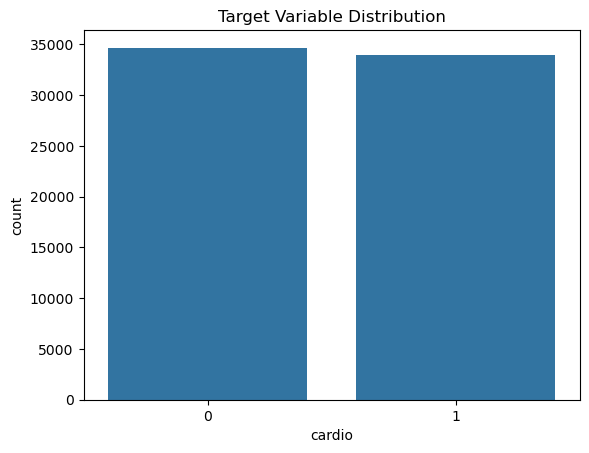

In [25]:
print(df['cardio'].value_counts())

sns.countplot(x='cardio', data=df)
plt.title("Target Variable Distribution")
plt.show()

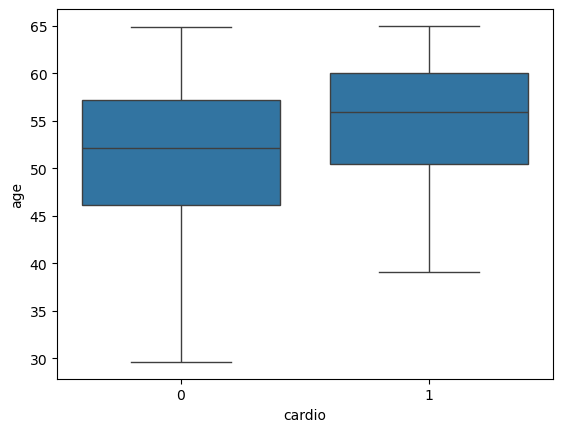

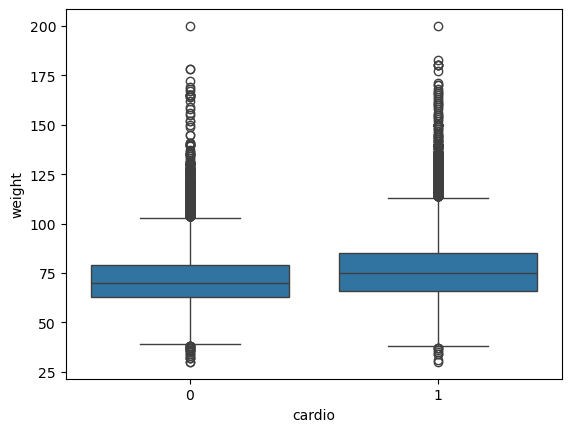

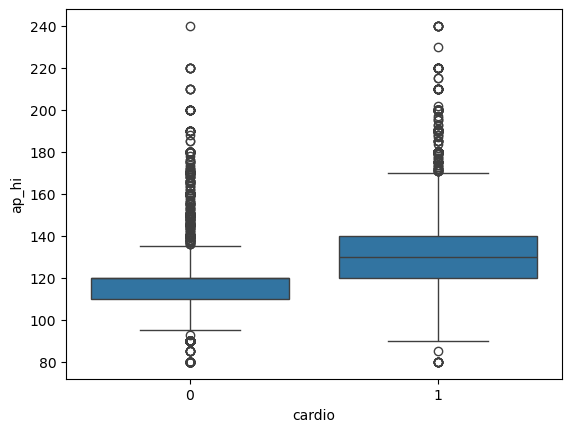

In [27]:
sns.boxplot(x='cardio', y='age', data=df)
plt.show()

sns.boxplot(x='cardio', y='weight', data=df)
plt.show()

sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.show()

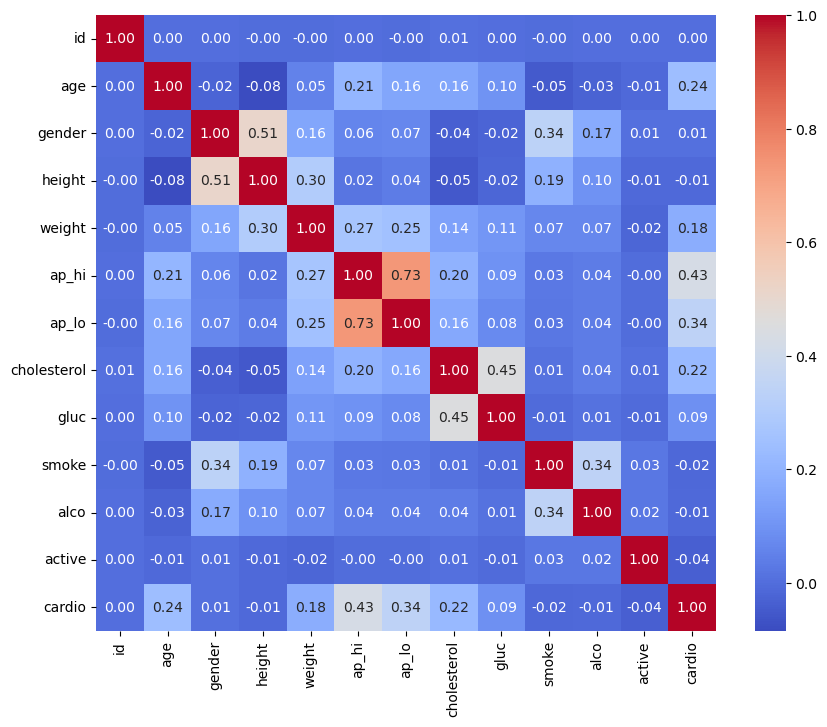

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

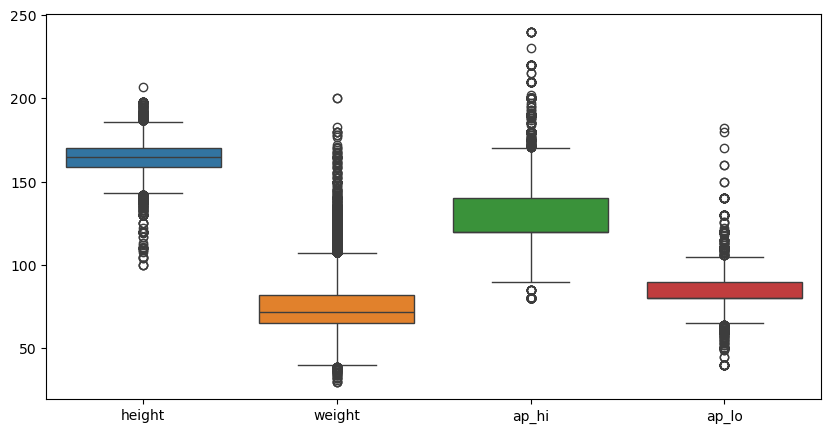

In [29]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['height','weight','ap_hi','ap_lo']])
plt.show()

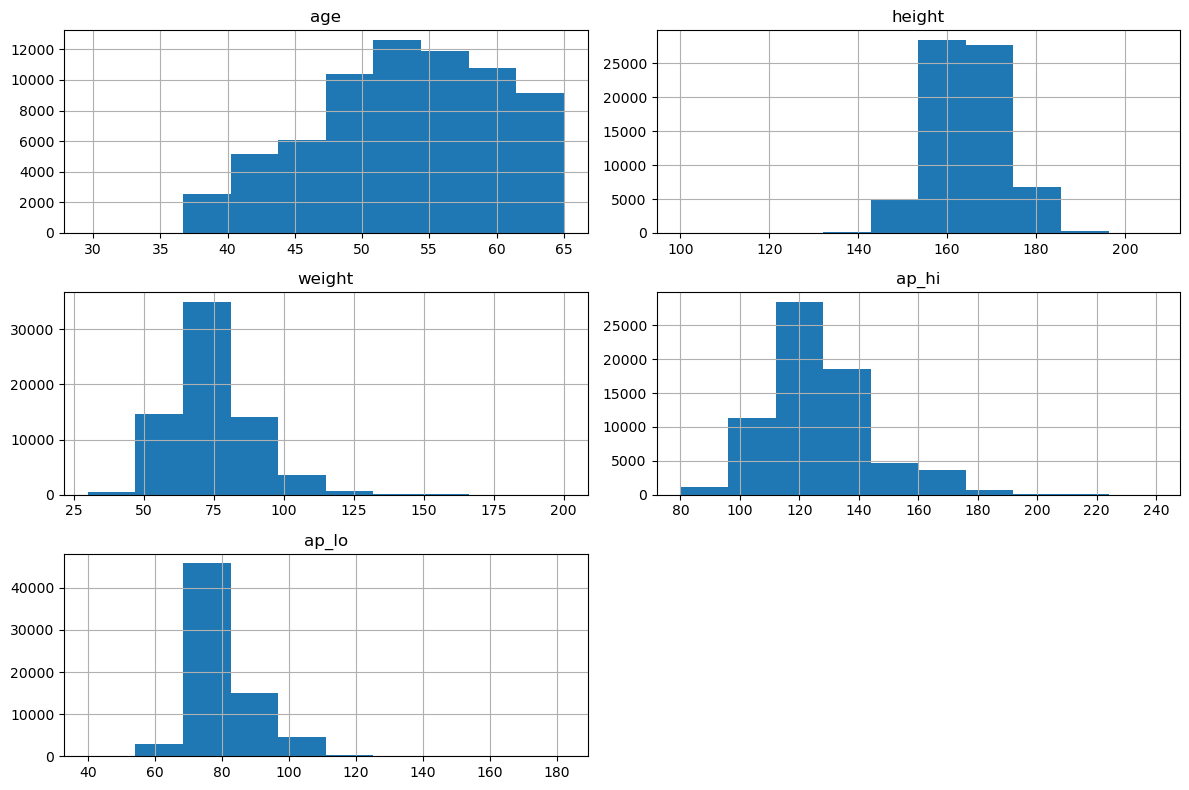

In [30]:
num_cols = ['age','height','weight','ap_hi','ap_lo']

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

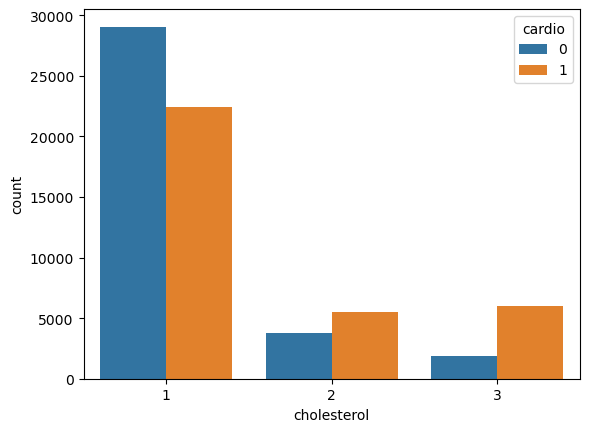

In [31]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.show()

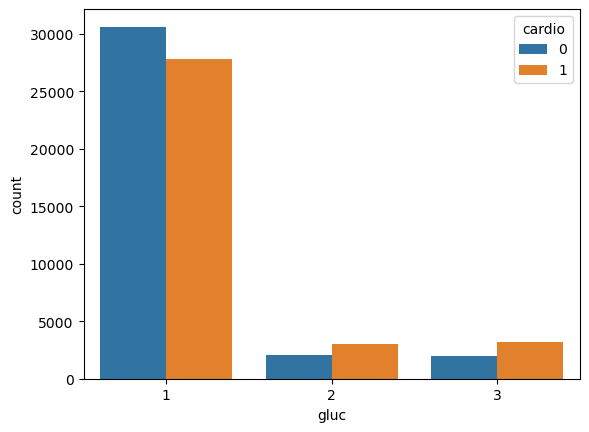

In [32]:
sns.countplot(x='gluc', hue='cardio', data=df)
plt.show()

In [33]:
pd.crosstab(df['smoke'], df['cardio'])

cardio,0,1
smoke,,
0,31468,31130
1,3208,2828


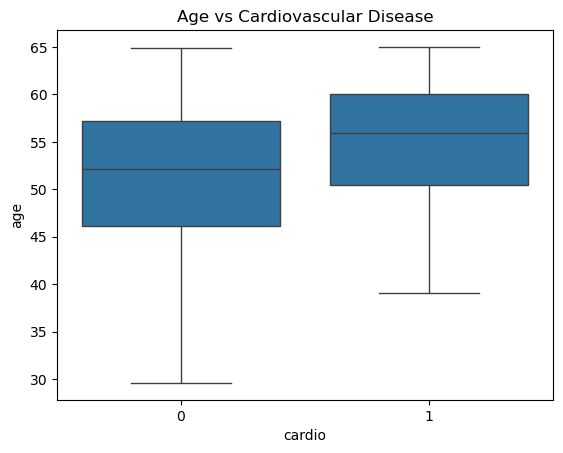

In [35]:
sns.boxplot(x='cardio', y='age', data=df)
plt.title("Age vs Cardiovascular Disease")
plt.show()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,pulse_pressure,MAP
39316,56154,0.0,2,171,57.0,110,80,1,1,1,0,0,1,19.493177,30,90.000000
44066,62957,0.0,1,163,67.0,110,70,2,1,0,0,0,0,25.217359,40,83.333333
25022,35739,0.0,2,154,52.0,120,80,1,1,0,0,0,0,21.926126,40,93.333333
23752,33949,0.0,1,155,58.0,160,100,3,1,0,0,1,1,24.141519,60,120.000000
37482,53526,0.0,2,174,67.0,110,70,1,1,0,0,1,1,22.129740,40,83.333333
18649,26631,0.0,2,168,82.0,140,90,1,1,0,0,1,1,29.053288,50,106.666667
1882,2661,0.0,1,160,95.0,110,90,2,1,0,0,1,0,37.109375,20,96.666667
5746,8172,0.0,1,150,76.0,120,80,3,1,0,0,1,1,33.777778,40,93.333333
68002,97117,0.0,2,170,70.0,120,80,1,1,0,0,1,0,24.221453,40,93.333333
37861,54049,0.0,1,169,70.0,120,80,1,1,0,0,1,0,24.508946,40,93.333333


In [47]:
df = df.drop('age', axis=1)

In [48]:
df.sample(3)

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,pulse_pressure,MAP
823,1144,1,166,73.0,110,70,2,1,0,1,1,0,26.491508,40,83.333333
20023,28598,1,155,80.0,170,100,3,1,0,0,1,1,33.298647,70,123.333333
44985,64251,1,168,60.0,110,70,1,1,0,0,1,0,21.258503,40,83.333333


In [49]:
X = df.drop(['id', 'cardio'], axis=1)
y = df['cardio']

In [50]:
print(X.shape)
print(y.shape)

(68634, 13)
(68634,)


In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (54907, 13)
Testing Set: (13727, 13)


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Done Successfully!")

Scaling Done Successfully!


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7265972171632549


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.6912653893785969


In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6482844030013841


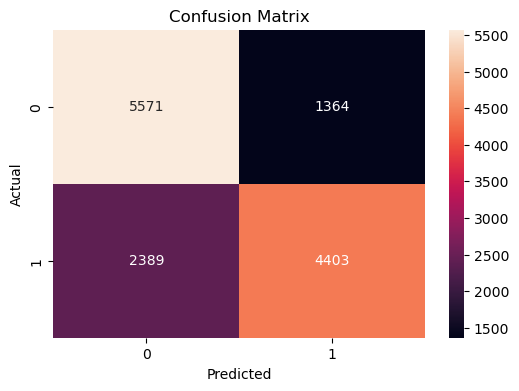

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.80      0.75      6935
           1       0.76      0.65      0.70      6792

    accuracy                           0.73     13727
   macro avg       0.73      0.73      0.72     13727
weighted avg       0.73      0.73      0.72     13727



In [58]:
import pickle

pickle.dump(lr, open('cardio_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print("Model Saved Successfully!")

Model Saved Successfully!
